In [108]:
# Standard library imports
import os
import io
import sys
import itertools
import random

# Third-party imports
import numpy as np
import pandas as pd
import h5py
import IPython
import PIL
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download
from scipy.ndimage import zoom

# PyTorch imports
import torch
from torch import nn
from torch.utils.data import Dataset, TensorDataset, DataLoader, random_split
import torchvision
from torchvision.utils import make_grid
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torchvision import models
from torchsummary import summary
from torchsummary import summary

In [109]:
events_file = "/home/owk24/ACDS_2/acds-storm-prediction-irma/data/events.csv"
train_file = "/home/owk24/ACDS_2/acds-storm-prediction-irma/data/train.h5"

In [110]:
def load_event(id):
    "Load event"
    with h5py.File(f'{train_file}','r') as f:
        event = {img_type: f[id][img_type][:] for img_type in ['vis', 'ir069', 'ir107', 'vil', 'lght']}
    return event


def normalise_sample(img):
    """
    Normalise image to [0, 1] range.
    """
    img = img - np.min(img)
    img = img / np.max(img)
    return img

### Adjusted Plotting Functions

In [133]:
def get_lightning_time_series(prediction, threshold=0.7):
    """
    Converts the given prediction (36 lightning maps of 36 frames of an event) 
    into a ligthning time series of that event.

    :param target: list of sparse matrices of shape (384, 384, 36) representing lightning strikes map for each frame
    :rtype: lightning time series of that prediction/event.
    """
    lght = []
    n_frames = 36 # assumes 36 frames
    # lightining strike values (in the map) above masked 
    # value are considered as lightnings
    mask_value = threshold

    # For each frame in the target
    prediction = prediction.reshape(384, 384, n_frames)
    for ti in range(n_frames):
        frame = prediction[:, :, ti]
        xs, ys = np.where(frame >= mask_value)
        
        # For each lightning strike in the frame
        for x, y in zip(xs, ys):
            count = frame[x, y]
            count = 1 if count > 0 else 0 # only store one lightning per location for now
            for _ in range(int(count)):
                lght.append([ti * 5 * 60, 0, 0, y, x])

    lght = np.array(lght)
    return lght

""" EVENT PLOTS WITH PREDICTIONS PER FRAME """
def plot_event_w_predictions(event, predicted_lght, frame=0):
    """
    Plots the event with 4 input image channels
    Plots target/label lightning strikes of the event
    Plots predicted/output lightning strikes of the event
    """

    t = event["lght"][:,0]# time of lightning strike (in seconds relative to first frame)
    if len(predicted_lght) != 0: t_pred = predicted_lght[:,0]

    def plot_frame(ti):
        f = (t >= ti*5*60 - 2.5*60) & (t < ti*5*60 + 2.5*60)# find which lightning strikes fall in current frame
        if len(predicted_lght) != 0: f_pred =  (t_pred >= ti*5*60 - 2.5*60) & (t_pred < ti*5*60 + 2.5*60)

        fig,axs = plt.subplots(1,5,figsize=(16,5))
        fig.suptitle(f"Baseline Model Prediction", fontsize=16)
        fig.text(0.5, 0.85, f"Event: {id}, Frame: {ti}, Time: {ti*5} min", fontsize=12, ha='center')
        axs[0].imshow(event["vis"][:,:,ti], vmin=0, vmax=10000, cmap="grey"), axs[0].set_title('Visible')
        axs[1].imshow(event["ir069"][:,:,ti], vmin=-8000, vmax=-1000, cmap="viridis"), axs[1].set_title('Infrared (Water Vapor)')
        axs[2].imshow(event["ir107"][:,:,ti], vmin=-7000, vmax=2000, cmap="inferno"), axs[2].set_title('Infrared (Cloud/Surface Temperature)')
        axs[3].imshow(event["vil"][:,:,ti], vmin=0, vmax=255, cmap="turbo"), axs[3].set_title('Radar')
        axs[3].scatter(event["lght"][f,3], event["lght"][f,4], marker="x", s=30, c="tab:red")
        axs[3].set_xlim(0,384), axs[3].set_ylim(384,0)

        axs[4].imshow(event["vil"][:,:,ti], vmin=0, vmax=255, cmap="turbo"), axs[4].set_title('Radar Predicted Strikes')
        if len(predicted_lght) != 0:
          axs[4].scatter(predicted_lght[f_pred,3], predicted_lght[f_pred,4], marker="x", s=30, c="tab:red")
          axs[4].set_xlim(0,384), axs[3].set_ylim(384,0)
        plt.show()
  
    plot_frame(frame)


""" EVENT PLOT WITH PREDICTIONS PER EVENT (GIF) """
def make_gif(outfile, files, fps=10, loop=0):
    "Helper function for saving GIFs"
    imgs = [PIL.Image.open(file) for file in files]
    imgs[0].save(fp=outfile, format='gif', append_images=imgs[1:],
                 save_all=True, duration=int(1000/fps), loop=loop)
    im = IPython.display.Image(filename=outfile)
    im.reload()
    return im

  
def plot_event_w_predictions_gif(event, predicted_lght, ids, output_gif=False, save_gif=False):
    t = event["lght"][:,0]# time of lightning strike (in seconds relative to first frame)
    if len(predicted_lght) != 0: t_pred = predicted_lght[:,0]

    def plot_frame(ti):
        f = (t >= ti*5*60 - 2.5*60) & (t < ti*5*60 + 2.5*60)# find which lightning strikes fall in current frame
        if len(predicted_lght) != 0: f_pred =  (t_pred >= ti*5*60 - 2.5*60) & (t_pred < ti*5*60 + 2.5*60)

        fig,axs = plt.subplots(1,5,figsize=(16,5))
        fig.suptitle(f"Baseline Model Prediction", fontsize=16)
        fig.text(0.5, 0.85, f"Event: {ids[0]}, Frame: {ti}, Time: {ti*5} min", fontsize=12, ha='center')
        axs[0].imshow(event["vis"][:,:,ti], vmin=0, vmax=10000, cmap="grey"), axs[0].set_title('Visible')
        axs[1].imshow(event["ir069"][:,:,ti], vmin=-8000, vmax=-1000, cmap="viridis"), axs[1].set_title('Infrared (Water Vapor)')
        axs[2].imshow(event["ir107"][:,:,ti], vmin=-7000, vmax=2000, cmap="inferno"), axs[2].set_title('Infrared (Cloud/Surface Temperature)')
        axs[3].imshow(event["vil"][:,:,ti], vmin=0, vmax=255, cmap="turbo"), axs[3].set_title('Radar')
        axs[3].scatter(event["lght"][f,3], event["lght"][f,4], marker="x", s=30, c="tab:red")
        axs[3].set_xlim(0,384), axs[3].set_ylim(384,0)

        axs[4].imshow(event["vil"][:,:,ti], vmin=0, vmax=255, cmap="turbo"), axs[4].set_title('Radar Predicted Strikes')
        if len(predicted_lght) != 0:
          axs[4].scatter(predicted_lght[f_pred,3], predicted_lght[f_pred,4], marker="x", s=30, c="tab:red")
          axs[4].set_xlim(0,384), axs[3].set_ylim(384,0)

        if output_gif:
            file = f"_temp_{id}_{ti}.png"
            fig.savefig(file, bbox_inches="tight", dpi=150, pad_inches=0.02, facecolor="white")
            plt.close()
        else:
            plt.show()
  
    if output_gif:
        for ti in range(36): plot_frame(ti)
        im = make_gif(f"{id}.gif", [f"_temp_{id}_{ti}.png" for ti in range(36)])
        for ti in range(36): os.remove(f"_temp_{id}_{ti}.png")
        IPython.display.display(im)
        if not save_gif: os.remove(f"{id}.gif")
    else:
        plot_frame(0)
        plot_frame(17)
        plot_frame(34)

### Basline Model:

**NOTE FOR ARAS:** Only change is to the get lightning function where I added a threshold argument.


In [113]:

def baseline_model(event, threshold=0.7):
    """
    Demonstrates the correlation between radar images and the location of lightning strikes.

    Parameters:
    - event (dict): A dictionary representing a single storm event.
    - threshold (float): A threshold value for generating the lightning time series.
    
    Returns:
    - numpy.ndarray: A lightning time series array with shape (N, 5).
    """
    # Normalise vil
    vil = normalise_sample(event["vil"])
    # Return lightning time series at a higher threshold
    lght = get_lightning_time_series(vil, threshold=threshold)

    return lght



In [134]:
# load event
df = pd.read_csv(events_file)
ids = df.id.unique()
event = load_event(ids[0])
lght = baseline_model(event)

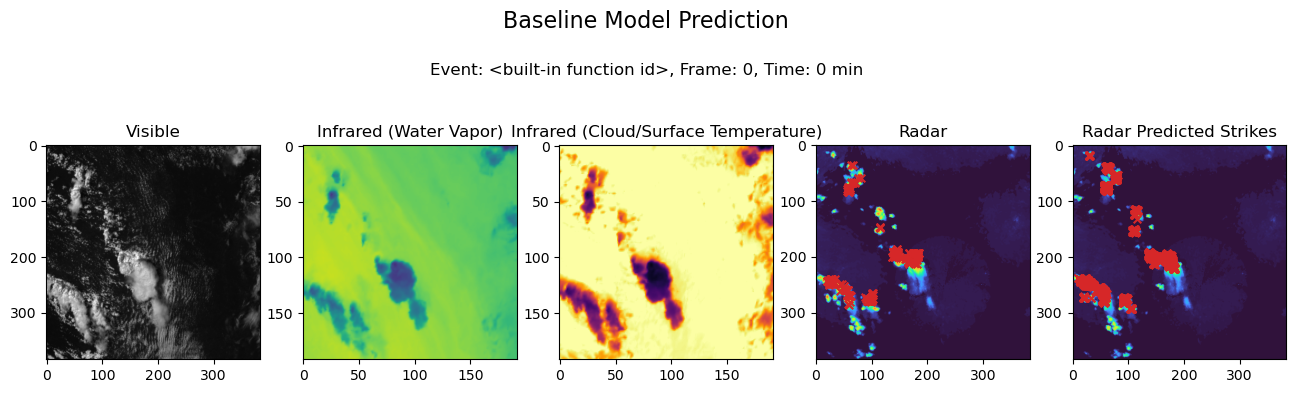

In [130]:
plot_event_w_predictions(event, lght, 0)

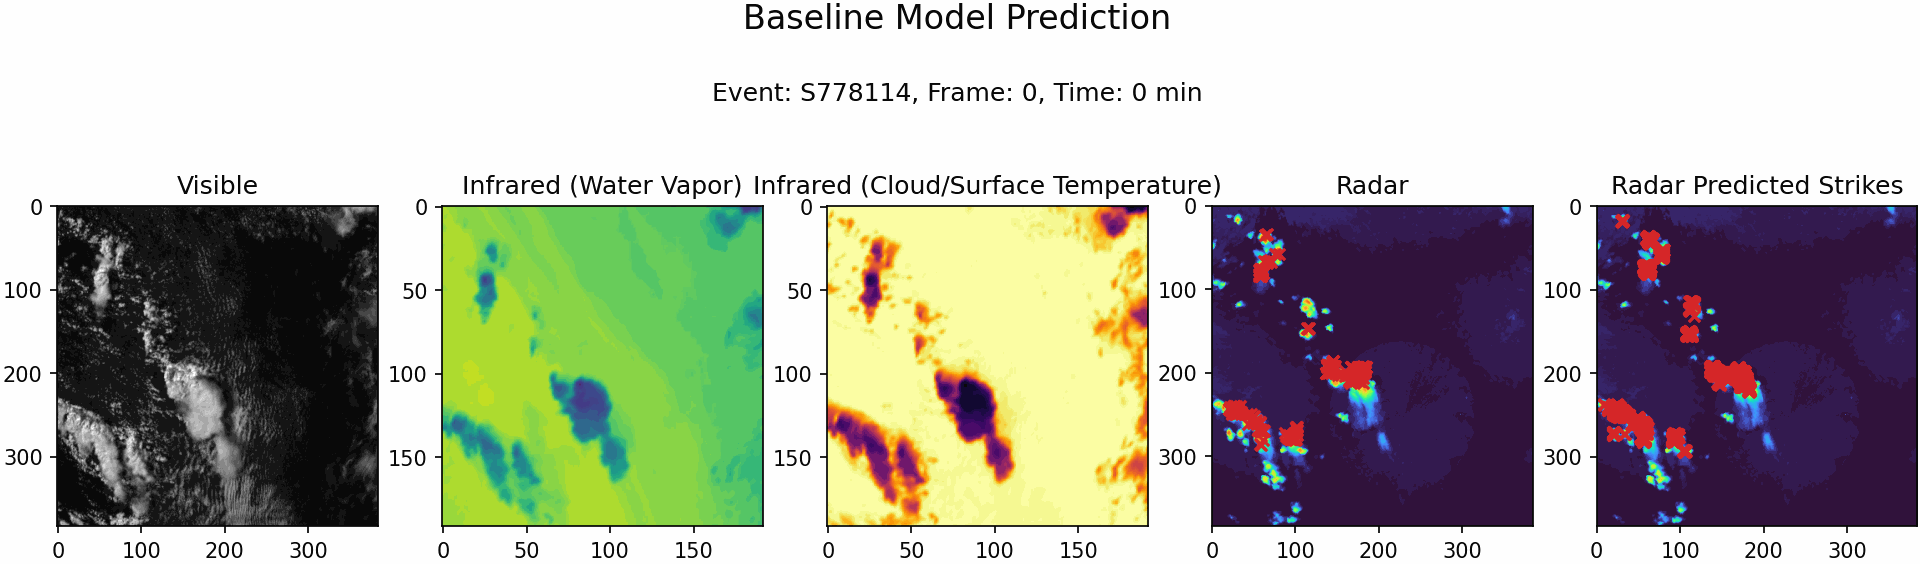

In [135]:
plot_event_w_predictions_gif(event, lght, ids, output_gif=True, save_gif=True)